# Data Acquisition & EDA

Load F-DATA + PM100, descriptive stats, EDA plots (Track B5): target distributions, correlation heatmaps, job-count-over-time, PM100 intra-job power traces.

See the conceptualization plan and EXPERIMENT_TRACKER.md for full context.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt

from src import config, features, metrics, plotting, models, roofline


## Load raw data

In [2]:
FDATA_DIR = "../data/raw/fdata"
PM100_PATH = "../data/raw/pm100/pm100_job_table.parquet"

# Iterate fast on a small sample (Decision #10: iterate on a stratified
# sample, only run full-scale for final numbers). Set to None to use
# every row once the notebook logic is verified stable.
SAMPLE_SIZE = 5000

import glob

fdata_files = sorted(glob.glob(f"{FDATA_DIR}/*.parquet"))
print(f"F-DATA monthly files found: {len(fdata_files)} / 38 expected")
print(fdata_files)

import pandas as pd
fdata = pd.concat([pd.read_parquet(f) for f in fdata_files], ignore_index=True)
pm100 = pd.read_parquet(PM100_PATH)

if SAMPLE_SIZE is not None:
    fdata = fdata.sample(n=min(SAMPLE_SIZE, len(fdata)), random_state=0).reset_index(drop=True)
    pm100 = pm100.sample(n=min(SAMPLE_SIZE, len(pm100)), random_state=0).reset_index(drop=True)
    print(f"\nSAMPLE_SIZE={SAMPLE_SIZE} active — using a random subsample for fast iteration, not the full dataset")

# F-DATA's datetime columns load as plain strings — parse once, up front,
# rather than repeatedly downstream.
FDATA_DATETIME_COLS = ["adt", "qdt", "schedsdt", "deldt", "sdt", "edt"]
for c in FDATA_DATETIME_COLS:
    fdata[c] = pd.to_datetime(fdata[c], errors="coerce")

pm100["submit_time"] = pd.to_datetime(pm100["submit_time"], unit="s", errors="coerce")
pm100["eligible_time"] = pd.to_datetime(pm100["eligible_time"], unit="s", errors="coerce")
pm100["start_time"] = pd.to_datetime(pm100["start_time"], unit="s", errors="coerce")
pm100["end_time"] = pd.to_datetime(pm100["end_time"], unit="s", errors="coerce")

print("\nfdata shape:", fdata.shape)
print("pm100 shape:", pm100.shape)
print("\nembedding column dtype:", fdata["embedding"].dtype, "- one 384-dim ndarray per row, excluded from describe() below")


F-DATA monthly files found: 1 / 38 expected
['../data/raw/fdata/fugaku_22_01.parquet']



SAMPLE_SIZE=5000 active — using a random subsample for fast iteration, not the full dataset

fdata shape: (5000, 45)
pm100 shape: (5000, 35)

embedding column dtype: object - one 384-dim ndarray per row, excluded from describe() below


**Note:** as of this notebook's last run, only 1 of the 38 expected F-DATA monthly files is present (`fugaku_22_01.parquet`, Jan 2022). The chronological split, rolling-window drift check (Decision #18), and full-scale run (Decision #10) all need the remaining months acquired before they're meaningful — this cell just reflects whatever's actually in `data/raw/fdata/` at the time it's run.

## Schema check

In [3]:
print("=== F-DATA dtypes ===")
print(fdata.dtypes)
print("\n=== PM100 dtypes ===")
print(pm100.dtypes)


=== F-DATA dtypes ===
jid                                    str
usr                                    str
jnam                                   str
cnumr                                int64
cnumat                               int64
cnumut                               int64
nnumr                                int64
adt              datetime64[us, UTC+09:00]
qdt              datetime64[us, UTC+09:00]
schedsdt         datetime64[us, UTC+09:00]
deldt            datetime64[us, UTC+09:00]
ec                                   int64
elpl                               float64
sdt              datetime64[us, UTC+09:00]
edt              datetime64[us, UTC+09:00]
nnuma                                int64
idle_time_ave                      float64
nnumu                                int64
perf1                              float64
perf2                              float64
perf3                              float64
perf4                              float64
perf5                           

## Confirm PM100 has no FLOP/performance-counter fields

This was already verified directly against PM100's `documentation/job_features.md` during planning (Decision #15) — re-checking here against the actual loaded dataframe as a belt-and-suspenders confirmation, not a new finding.

In [4]:
flop_like = [c for c in pm100.columns if any(k in c.lower() for k in ["flop", "perf", "cycle", "instr", "bandwidth", "mbwidth", "opint"])]
print("PM100 columns matching FLOP/performance-counter-like names:", flop_like)
assert flop_like == [], "Unexpected: PM100 appears to have a performance-counter field after all — revisit Decision #15"

print("\nF-DATA equivalents (for contrast):", [c for c in fdata.columns if c in ("flops", "mbwidth", "opint", "pclass", "perf1", "perf2", "perf3", "perf4", "perf5", "perf6")])


PM100 columns matching FLOP/performance-counter-like names: []

F-DATA equivalents (for contrast): ['perf1', 'perf2', 'perf3', 'perf4', 'perf5', 'perf6', 'flops', 'mbwidth', 'opint', 'pclass']


## Missingness

In [5]:
print("=== F-DATA missing value counts (nonzero only) ===")
print(fdata.isna().sum().loc[lambda s: s > 0])
print("\n=== PM100 missing value counts (nonzero only) ===")
print(pm100.isna().sum().loc[lambda s: s > 0])


=== F-DATA missing value counts (nonzero only) ===
Series([], dtype: int64)

=== PM100 missing value counts (nonzero only) ===
num_tasks            180
req_nodes           4403
threads_per_core    4982
dtype: int64


## Descriptive statistics

`embedding` is excluded — it's a 384-dim `ndarray` per row, not something `describe()`'s unique/top/freq machinery can handle (this is what caused the first execution attempt to hang: pandas trying to hash/compare unhashable numpy arrays across 1.3M rows).

In [6]:
fdata_numeric = fdata.select_dtypes(include="number")
fdata_categorical = fdata.drop(columns=["embedding"]).select_dtypes(exclude="number")

print("=== F-DATA numeric columns ===")
display(fdata_numeric.describe().T)
print("\n=== F-DATA non-numeric columns (excluding embedding) ===")
display(fdata_categorical.describe().T)


=== F-DATA numeric columns ===


,count,mean,std,min,25%,50%,75%,max
cnumr,5000.0,6.741312e+02,4.477465e+03,4.800000e+01,4.800000e+01,4.800000e+01,1.920000e+02,1.152000e+05
cnumat,5000.0,6.741312e+02,4.477465e+03,4.800000e+01,4.800000e+01,4.800000e+01,1.920000e+02,1.152000e+05
cnumut,5000.0,5.556224e+02,4.064453e+03,1.200000e+01,1.200000e+01,4.800000e+01,4.800000e+01,9.830400e+04
nnumr,5000.0,1.404440e+01,9.328052e+01,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,2.400000e+03
ec,5000.0,2.066600e+00,2.013340e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.550000e+02
elpl,5000.0,1.399202e+04,4.198980e+04,6.000000e+01,9.000000e+02,3.600000e+03,3.600000e+03,2.592000e+05
nnuma,5000.0,2.625660e+01,1.059197e+02,1.000000e+00,1.000000e+00,1.000000e+00,4.800000e+01,2.880000e+03
idle_time_ave,5000.0,1.093150e+03,6.524633e+03,9.949455e-01,3.515947e+01,1.243775e+02,4.334766e+02,2.018770e+05
nnumu,5000.0,1.310420e+01,9.331956e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.400000e+03
perf1,5000.0,6.156922e+15,6.890608e+16,3.654408e+08,3.239287e+11,5.591812e+12,1.555631e+14,2.162377e+18



=== F-DATA non-numeric columns (excluding embedding) ===


,count,unique,top,freq,mean,min,25%,50%,75%,max
jid,5000,4915,jid_5674960,7,NaN,NaN,NaN,NaN,NaN,NaN
usr,5000,170,usr_1226,850,NaN,NaN,NaN,NaN,NaN,NaN
jnam,5000,1227,jnam_47,2004,NaN,NaN,NaN,NaN,NaN,NaN
adt,5000,NaN,NaN,NaN,2022-01-17 18:28:55.315400+09:00,2022-01-01 00:00:05+09:00,2022-01-06 16:54:10+09:00,2022-01-19 12:56:31.500000+09:00,2022-01-27 21:52:35.250000+09:00,2022-01-31 23:59:59+09:00
qdt,5000,NaN,NaN,NaN,2022-01-17 18:29:10.042800+09:00,2022-01-01 00:00:25+09:00,2022-01-06 16:54:10+09:00,2022-01-19 12:56:31.500000+09:00,2022-01-27 21:52:35.250000+09:00,2022-02-01 00:00:00+09:00
schedsdt,5000,NaN,NaN,NaN,2022-01-17 23:22:14.917199+09:00,2022-01-01 00:00:31+09:00,2022-01-06 22:27:46.750000+09:00,2022-01-19 22:53:01.500000+09:00,2022-01-28 21:23:53.250000+09:00,2022-02-08 15:35:29+09:00
deldt,5000,NaN,NaN,NaN,1970-01-01 09:00:00+09:00,1970-01-01 09:00:00+09:00,1970-01-01 09:00:00+09:00,1970-01-01 09:00:00+09:00,1970-01-01 09:00:00+09:00,1970-01-01 09:00:00+09:00
sdt,5000,NaN,NaN,NaN,2022-01-17 23:22:53.663800+09:00,2022-01-01 00:00:52+09:00,2022-01-06 22:28:04.500000+09:00,2022-01-19 22:53:38+09:00,2022-01-28 21:24:38.500000+09:00,2022-02-08 15:38:03+09:00
edt,5000,NaN,NaN,NaN,2022-01-18 00:31:01.722800+09:00,2022-01-01 00:06:11+09:00,2022-01-06 23:23:09+09:00,2022-01-19 23:08:49+09:00,2022-01-29 01:42:37.250000+09:00,2022-02-09 00:05:29+09:00
jobenv_req,5000,1,jobenv_req_0,5000,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
pm100.describe(include="all").T  # no embedding/array columns here, so this is fine as-is


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
cores_alloc_layout,5000,3212,"{661: [0, 1, 2, 3]}",43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cores_allocated,5000,3118,{661: 16},48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cores_per_task,5000.0,NaN,NaN,NaN,16.2056,1.0,1.0,16.0,32.0,128.0,16.325411
derived_ec,5000,30,0:0,2587,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eligible_time,5000,NaN,NaN,NaN,2020-08-07 00:52:03.135600+00:00,2020-05-06 07:45:12+00:00,2020-06-24 15:51:14.250000+00:00,2020-08-16 09:00:34+00:00,2020-09-23 05:55:53+00:00,2020-10-13 03:48:58+00:00,NaN
end_time,5000,NaN,NaN,NaN,2020-08-07 03:32:09.098800+00:00,2020-05-06 09:49:20+00:00,2020-06-24 16:48:55+00:00,2020-08-16 10:24:24.500000+00:00,2020-09-23 07:30:02.750000+00:00,2020-10-13 03:51:04+00:00,NaN
group_id,5000.0,NaN,NaN,NaN,25211.3128,25200.0,25200.0,25200.0,25200.0,53482.0,565.583422
job_id,5000.0,NaN,NaN,NaN,3132120.4314,2437.0,1567270.0,3116288.0,4695408.75,6242697.0,1802715.337324
job_state,5000,6,COMPLETED,3952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nodes,5000,2177,[661],59,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Target distributions (raw vs. log1p)

Targets per Decision #2/#3: F-DATA → `duration` (execution time), `mmszu` (memory used), `avgpcon` (power). PM100 → `run_time`, `mem_alloc` (no "used" field exists — this is the Decision #2 fallback case, not a choice), `node_power_consumption`.

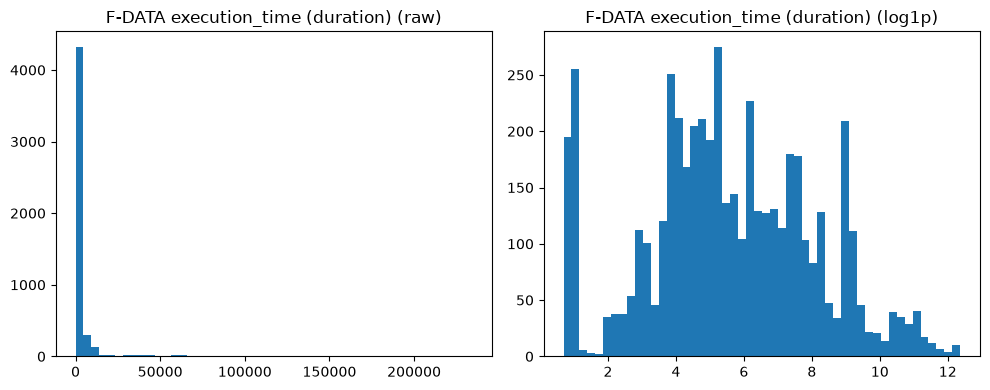

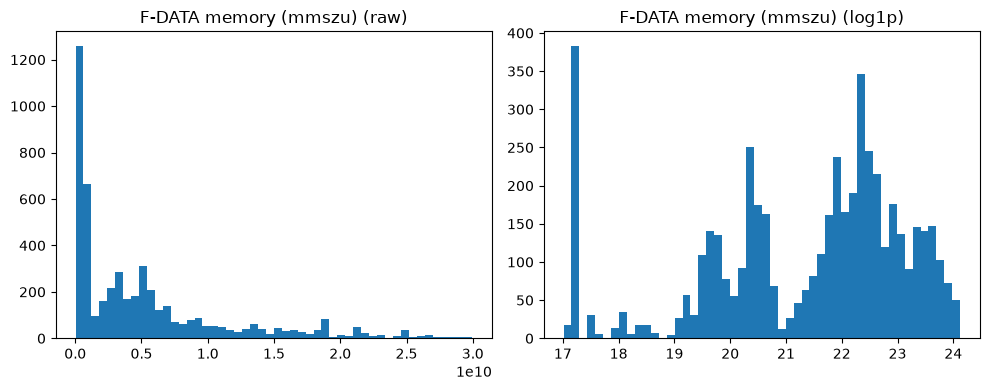

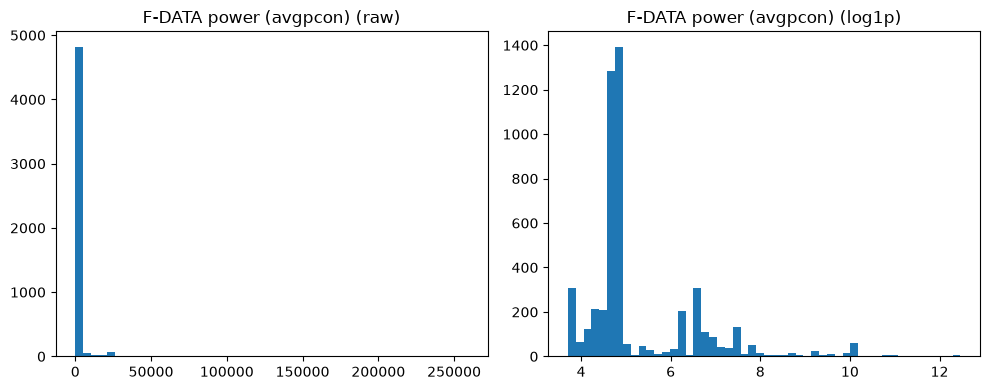

In [8]:
import numpy as np

for name, col in features.FDATA_TARGETS.items():
    vals = fdata[col].dropna().to_numpy()
    vals = vals[vals >= 0]  # log1p requires non-negative
    fig = plotting.plot_target_distribution(vals, np.log1p(vals), f"F-DATA {name} ({col})")
    plt.show()


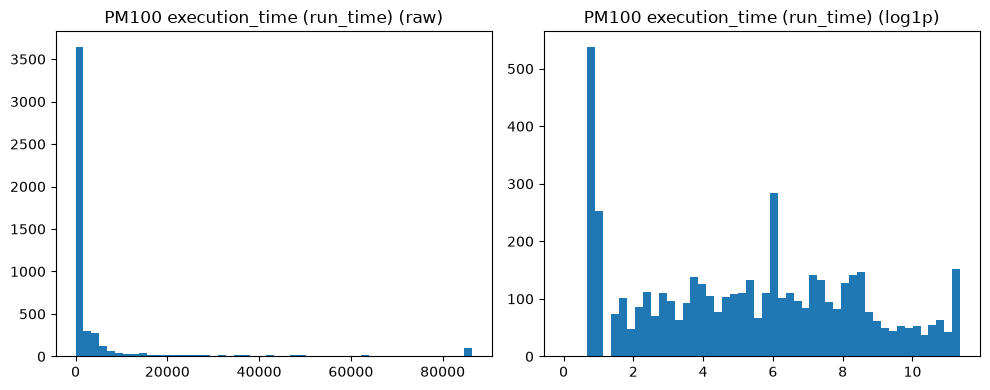

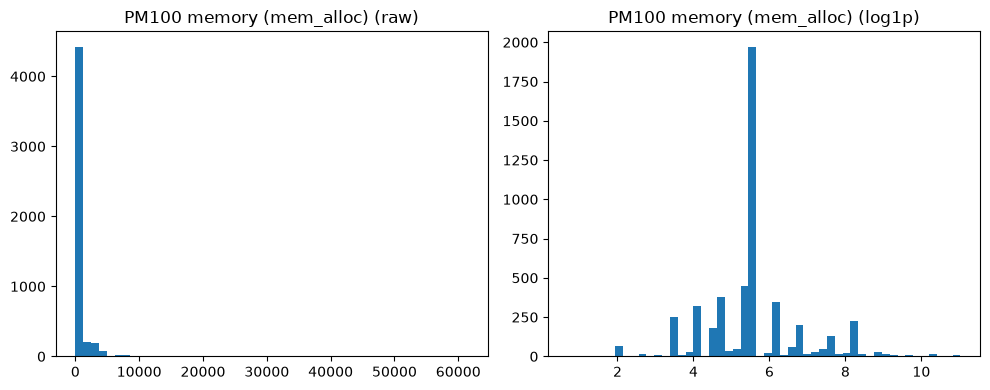

PM100 power (node_power_consumption): array-valued per job (e.g. length 63 samples) — plotting per-job mean


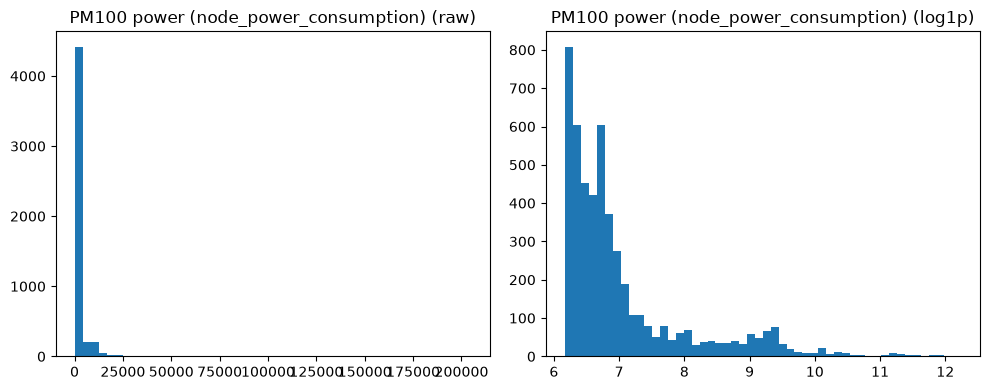

In [9]:
for name, col in features.PM100_TARGETS.items():
    series = pm100[col].dropna()
    if len(series) and hasattr(series.iloc[0], "__len__"):
        # node_power_consumption is a per-job time series (20s-interval
        # samples, Decision #13's LSTM/TCN sequence input) — reduce to a
        # per-job mean for this scalar distribution plot; the raw sequence
        # is used as-is later for LSTM/TCN, not flattened here.
        vals = series.apply(lambda arr: float(np.mean(arr))).to_numpy()
        print(f"PM100 {name} ({col}): array-valued per job (e.g. length {len(series.iloc[0])} samples) — plotting per-job mean")
    else:
        vals = series.to_numpy()
    vals = vals[vals >= 0]
    fig = plotting.plot_target_distribution(vals, np.log1p(vals), f"PM100 {name} ({col})")
    plt.show()


## Job-count-over-time

Justifies the chronological train/test split, and — once more F-DATA months are present — will show whether there's an obvious basis for the rolling-window drift check window size (Decision #18).

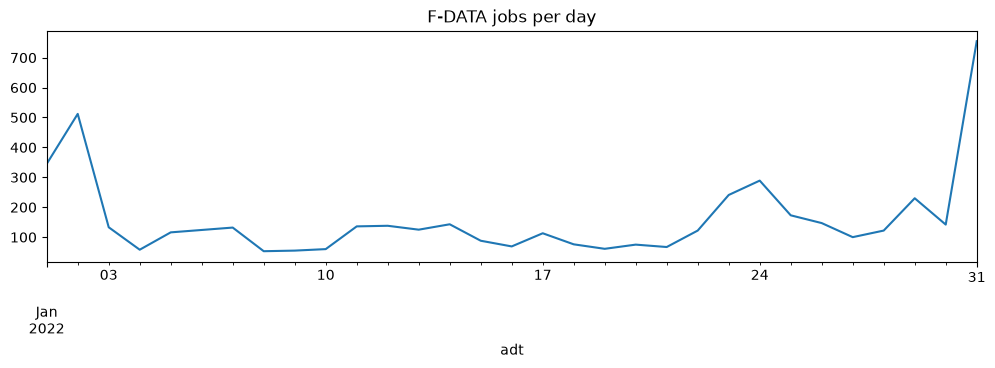

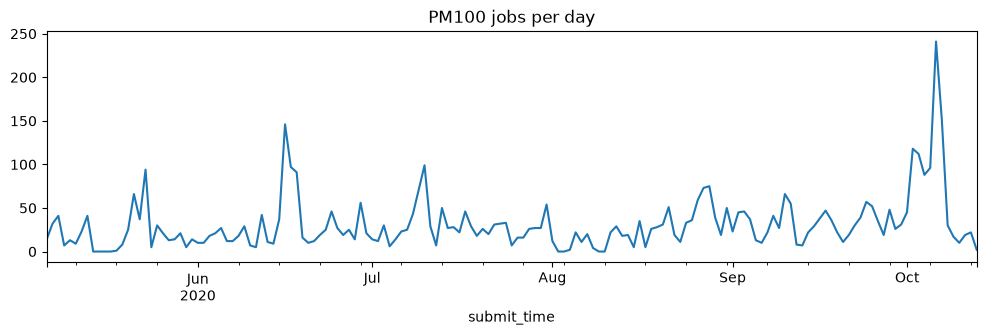

In [10]:
fdata.set_index("adt").resample("D").size().plot(figsize=(12, 3), title="F-DATA jobs per day")
plt.show()

pm100.set_index("submit_time").resample("D").size().plot(figsize=(12, 3), title="PM100 jobs per day")
plt.show()


## Tier A/B feature-matrix sanity check

Confirms `src/features.py`'s column lists actually apply cleanly to the loaded data (already validated once from the command line — this is the in-notebook, repeatable version of that check).

In [11]:
for name, df, dataset in [("F-DATA", fdata, "fdata"), ("PM100", pm100, "pm100")]:
    tier_a = features.build_tier_a_features(df, dataset)
    tier_b = features.build_tier_b_features(df, dataset)
    features.assert_no_tier_leakage(list(tier_a.columns), "A", dataset)
    features.assert_no_tier_leakage(list(tier_b.columns), "B", dataset)
    print(f"{name}: Tier A {tier_a.shape}, Tier B {tier_b.shape} — OK, no leakage")


F-DATA: Tier A (5000, 13), Tier B (5000, 30) — OK, no leakage
PM100: Tier A (5000, 18), Tier B (5000, 15) — OK, no leakage
